# Imports and Functions

In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [28]:
def csv_to_pd(path:str) -> pd.DataFrame:
    ''' picks up a CSV and returns a df'''
    tmp = pd.read_csv(path)
    tmp_pd = pd.DataFrame(data=tmp)
    return tmp_pd

In [29]:
def spilt_Meso1(dataframe:pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    '''spilts the phase 1 dataframe into the different workouts'''
    df1 = dataframe.iloc[:8]
    df2 = dataframe.iloc[8:]
    return df1, df2

In [30]:
def remove_columns_raw(dataframe: pd.DataFrame) -> pd.DataFrame:
    '''this removes two columns which are needed for any df and returns a new df,
    which we call raw since it keeps a lot of info which we won't use for data exploration/analysis'''
    drop_columns = (['Unnamed: 0', 'LOADING PROGRESSION'])
    df_raw = dataframe.drop(drop_columns, axis=1)
    return df_raw

In [31]:
def create_bodyweight_pd(dates:list, weight_kg:list, body_fat:list, muscle_mass:list) -> pd.DataFrame:
    '''creates a dataframe with bodyweight, body fat % and muscle mass %'''
    df = pd.DataFrame(data=(weight_kg, body_fat, muscle_mass))
    df_t = df.transpose()
    df_t = df_t.set_axis(dates, axis=0) 
    df_t = df_t.set_axis(["Weight kg", "Body Fat %", "Muscle Mass %"], axis=1, inplace=False)
    return df_t

In [32]:


def remove_columns_exploration(dataframe: pd.DataFrame) -> pd.DataFrame:
    '''removes the columns which aren't needed for data exploration/analysis'''
    drop_columns = (['SETS', 'REPS', 'REST'])
    df = dataframe.drop(drop_columns, axis=1)
    return df

# Data prepping

In [33]:
dates = ("14/09", "12/10", "26/10", "2/11", "9/11", "16/11", "23/11", "30/11", "7/12","14/12", "21/12", "28/12", "4/1", "11/1", "18/1", "25/1", "1/2", "8/2", "13/2", "15/2", "23/2", "27/2", "4/3", "6/3", "11/3" )
weight_kg = (93.1, 91.6, 93.3, 93, 92.7, 92.6, 91.6, 91.8, 93.2, 92.1, 92, 91.6, 92.5, 92.1, 91.3, 91.2, 89.8, 90.0, 90.1, 90.2, 92, 90.5, 91, 91.9, 90.3)
body_fat = (0, 0, 0, 0, 0, 0, 24.2, 0, 15.6, 17.0, 0, 0, 0, 17.8, 15.6, 15.3, 22.4, 22.1, 19.4, 36.5, 11.7, 35.4, 24.1, 18.9, 26.6 )
muscle_mass = (0, 0, 0, 0, 0, 0, 40.6, 0, 46.3, 45.5, 0, 0, 0, 42, 46, 46.5, 41.6, 42, 40.7, 30.5, 52.3, 31.7, 35,  41.3, 33.9 )

In [34]:
bodyweight_pd = create_bodyweight_pd(dates, weight_kg, body_fat, muscle_mass)
bodyweight_pd

,Weight kg,Body Fat %,Muscle Mass %
14/09,93.1,0.0,0.0
12/10,91.6,0.0,0.0
26/10,93.3,0.0,0.0
2/11,93.0,0.0,0.0
9/11,92.7,0.0,0.0
16/11,92.6,0.0,0.0
23/11,91.6,24.2,40.6
30/11,91.8,0.0,0.0
7/12,93.2,15.6,46.3
14/12,92.1,17.0,45.5


In [35]:
phase1 = csv_to_pd("gym_data/Hugo D' Arcy - Meso 1.csv")
phase1_raw = remove_columns_raw(phase1)
phase1_chest_raw, phase1_back_raw = spilt_Meso1(phase1_raw)

In [36]:
phase1_chest_raw

,WORK OUT A CHEST FOCUIS,SETS,REPS,REST,WEEK 1,WEEK 2,WEEK 3,WEEK 4,WEEK 5,WEEK 6,...,WEEK 12,WEEK 13,WEEK 14,WEEK 15,WEEK 16,WEEK 17,WEEK 18,WEEK 19,WEEK 20,WEEK 21
0,MAIN COMPONENT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,STANDING ROW MACHINE,3,12-15FF,60-120 SEC,20,"22.5 keep it (12,9,8)",22.5x2,25 (9 last ),"30,25,20",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,FARMER WALK,3,12-15FF,60-120 SEC,20,20,20,20,20,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,HIP THRUST,3,12-15FF,60-120 SEC,MACHINE,"2,5",5,5,10,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,SINGLE SHOULDER PRESS,3,12-15FF,60-120 SEC,9,10(12),"10(11,10,9)",10(15),12(10reps),NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,HAMMER CURLS,3,12-15FF,60-120 SEC,8,7,8x1,8,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,POLIERCOLINA,3,12-15FF,60-120 SEC,15,10,12.5x1,12.5,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,CABLE DEAD BUG,3,12-15FF,60-120 SEC,"7,5",BAND,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
phase1_back_raw

,WORK OUT A CHEST FOCUIS,SETS,REPS,REST,WEEK 1,WEEK 2,WEEK 3,WEEK 4,WEEK 5,WEEK 6,...,WEEK 12,WEEK 13,WEEK 14,WEEK 15,WEEK 16,WEEK 17,WEEK 18,WEEK 19,WEEK 20,WEEK 21
8,WORK OUT B BACK FOCUS,SETS,REPS,REST,WEEK 1,WEEK 2,WEEK 3,WEEK 4,WEEK 5,WEEK 6,...,WEEK 12,WEEK 13,WEEK 14,WEEK 15,WEEK 16,WEEK 17,WEEK 18,WEEK 19,WEEK 20,WEEK 21
9,MAIN COMPONENT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,LAT PULL DOWN NARROW GRIP,3,12-15FF,60-120 SEC,30 hard,27.5,"30, 30x8 (finished the rest on 30), 25",GO UNI,UNI 20,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,FARMER WALK,3,12-15FF,60-120 SEC,20,20,20,20 x50 sec,22,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,DB BENCH PRESS,3,12-15FF,60-120 SEC,10,"12,12(10),10","12,12, 12x6, 10",12x3,14 go slow,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,FRONT SQUAT ELEVATED,3,12-15FF,60-120 SEC,BW paused,4 x2,"Bw (forgot we did it weighed),4,4",5x2 PAUSED,6,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,SEATED DB CURLS,3,12-15FF,60-120 SEC,7,NaN,"8x15, 8x12, 8x10",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,SEATED FRENCH PRESS,3,12-15FF,60-120 SEC,9,NaN,"6x12,6x12,6x12",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,FELLOW PRESS,3,12-15FF,60-120 SEC,NaN,NaN,7.5,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
phase1_pd = remove_columns_exploration(phase1_raw)
phase1_chest, phase1_back = spilt_Meso1(phase1_pd)
phase1_chest

,WORK OUT A CHEST FOCUIS,WEEK 1,WEEK 2,WEEK 3,WEEK 4,WEEK 5,WEEK 6,WEEK 7,WEEK 8,WEEK 9,...,WEEK 12,WEEK 13,WEEK 14,WEEK 15,WEEK 16,WEEK 17,WEEK 18,WEEK 19,WEEK 20,WEEK 21
0,MAIN COMPONENT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,STANDING ROW MACHINE,20,"22.5 keep it (12,9,8)",22.5x2,25 (9 last ),"30,25,20",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,FARMER WALK,20,20,20,20,20,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,HIP THRUST,MACHINE,"2,5",5,5,10,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,SINGLE SHOULDER PRESS,9,10(12),"10(11,10,9)",10(15),12(10reps),NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,HAMMER CURLS,8,7,8x1,8,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,POLIERCOLINA,15,10,12.5x1,12.5,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,CABLE DEAD BUG,"7,5",BAND,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
phase1_back

,WORK OUT A CHEST FOCUIS,WEEK 1,WEEK 2,WEEK 3,WEEK 4,WEEK 5,WEEK 6,WEEK 7,WEEK 8,WEEK 9,...,WEEK 12,WEEK 13,WEEK 14,WEEK 15,WEEK 16,WEEK 17,WEEK 18,WEEK 19,WEEK 20,WEEK 21
8,WORK OUT B BACK FOCUS,WEEK 1,WEEK 2,WEEK 3,WEEK 4,WEEK 5,WEEK 6,WEEK 7,WEEK 8,WEEK 9,...,WEEK 12,WEEK 13,WEEK 14,WEEK 15,WEEK 16,WEEK 17,WEEK 18,WEEK 19,WEEK 20,WEEK 21
9,MAIN COMPONENT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,LAT PULL DOWN NARROW GRIP,30 hard,27.5,"30, 30x8 (finished the rest on 30), 25",GO UNI,UNI 20,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,FARMER WALK,20,20,20,20 x50 sec,22,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,DB BENCH PRESS,10,"12,12(10),10","12,12, 12x6, 10",12x3,14 go slow,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,FRONT SQUAT ELEVATED,BW paused,4 x2,"Bw (forgot we did it weighed),4,4",5x2 PAUSED,6,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,SEATED DB CURLS,7,NaN,"8x15, 8x12, 8x10",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,SEATED FRENCH PRESS,9,NaN,"6x12,6x12,6x12",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,FELLOW PRESS,NaN,NaN,7.5,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
phase1_chest.columns = phase1_chest.columns.astype(str)

In [41]:
words_to_replace = ('MACHINE','BW', 'BAND')
phase1_chest = phase1_chest.replace(words_to_replace, 0)
#phase1_chest = phase1_chest.replace('BW', 0)
phase1_chest = phase1_chest.replace(r'x.*', '', regex=True)
phase1_chest = phase1_chest.replace(r'(\d+).*', r'\1', regex=True)
# df_t = df_t.set_axis(dates, axis=0) 
phase1_chest = phase1_chest.set_axis(phase1_chest["WORK OUT A CHEST FOCUIS"], axis=0)
phase1_chest = phase1_chest.drop("WORK OUT A CHEST FOCUIS", axis=1)
phase1_chest = phase1_chest.drop("MAIN COMPONENT", axis=0)
phase1_chest.columns

Index(['WEEK 1', 'WEEK 2', 'WEEK 3', 'WEEK 4', 'WEEK 5', 'WEEK 6', 'WEEK 7',
       'WEEK 8', 'WEEK 9', 'WEEK 10', 'WEEK 11', 'WEEK 12', 'WEEK 13',
       'WEEK 14', 'WEEK 15', 'WEEK 16', 'WEEK 17', 'WEEK 18', 'WEEK 19',
       'WEEK 20', 'WEEK 21'],
      dtype='object')

In [42]:
phase1_clean = phase1_chest.fillna(0)
test_graph = phase1_clean.T
test_graph

WORK OUT A CHEST FOCUIS,STANDING ROW MACHINE,FARMER WALK,HIP THRUST,SINGLE SHOULDER PRESS,HAMMER CURLS,POLIERCOLINA,CABLE DEAD BUG
WEEK 1,20,20,0,9,8,15,7
WEEK 2,22,20,2,10,7,10,0
WEEK 3,22,20,5,10,8,12,0
WEEK 4,25,20,5,10,8,12,0
WEEK 5,30,20,10,12,0,0,0
WEEK 6,0.0,0.0,0.0,0.0,0.0,0.0,0.0
WEEK 7,0.0,0.0,0.0,0.0,0.0,0.0,0.0
WEEK 8,0.0,0.0,0.0,0.0,0.0,0.0,0.0
WEEK 9,0.0,0.0,0.0,0.0,0.0,0.0,0.0
WEEK 10,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Graphs

<AxesSubplot:xlabel='HIP THRUST'>

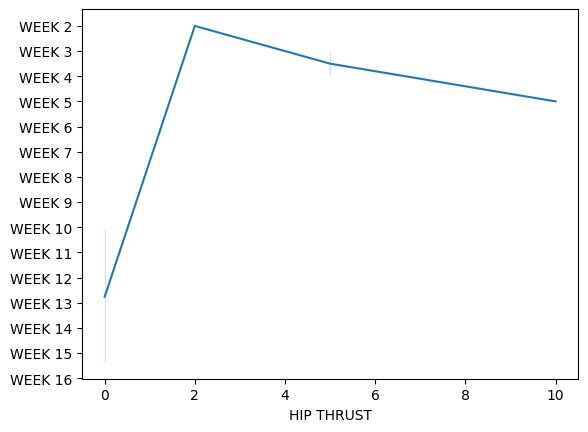

In [43]:
sns.lineplot(x=test_graph["HIP THRUST"], y=test_graph.index)

<AxesSubplot:ylabel='Weight kg'>

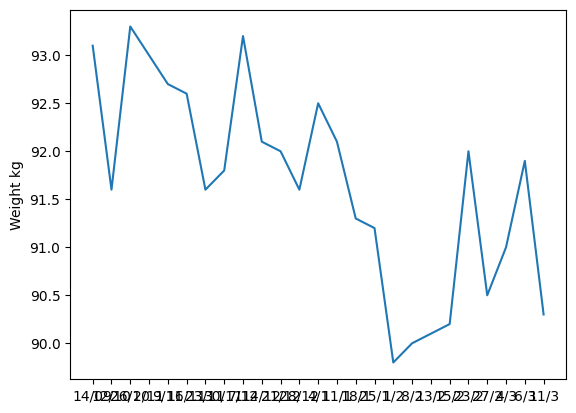

In [44]:
sns.lineplot(x=bodyweight_pd.index, y=bodyweight_pd["Weight kg"])

<AxesSubplot:ylabel='Weight kg'>

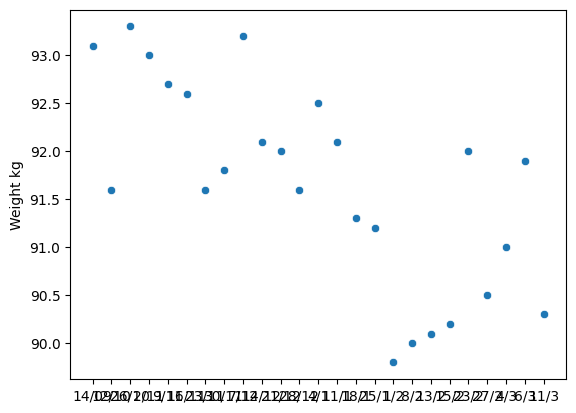

In [45]:
sns.scatterplot(x=bodyweight_pd.index, y=bodyweight_pd["Weight kg"])

# Scrap work might use later

In [46]:
#phase1_pd.set_index("WORK OUT A CHEST FOCUIS", inplace=True)
#phase1_pd